Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: /content/Hemoglobin/train, Val: /content/Hemoglobin/validation
Found 1373 images belonging to 3 classes.
Found 129 images belonging to 3 classes.

Training: 1373, Validation: 129
Class weights: {0: np.float64(1.2075637642919965), 1: np.float64(1.1081517352703794), 2: np.float64(0.7877223178427998)}
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 4, 4, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,249,043 (23.84 MB)

 Trainable params: 329,219 (1.26 MB)

 Non-trainable params: 5,919,824 (22.58 MB)


PHASE 1: Training with frozen base
Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.6115 - f1_score: 0.6069 - loss: 1.0960 - precision: 0.6243 - recall: 0.5797
Epoch 1: val_accuracy improved from None to 0.36434, saving model to efficientnetv2_best.keras

Epoch 1: finished saving model to efficientnetv2_best.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 44s 693ms/step - accuracy: 0.7123 - f1_score: 0.7095 - loss: 0.8343 - precision: 0.7249 - recall: 0.6948 - val_accuracy: 0.3643 - val_f1_score: 0.1946 - val_loss: 1.6204 - val_precision: 0.3643 - val_recall: 0.3643 - learning_rate: 0.0010
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.7450 - f1_score: 0.7464 - loss: 0.6650 - precision: 0.7508 - recall: 0.7258
Epoch 2: val_accuracy improved from 0.36434 to 0.39535, saving model to efficientnetv2_best.keras

Epoch 2: finished saving model to efficientnetv2_best.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 23s 541ms/step - accuracy: 0.7786 - f1_score: 0.7790 - loss: 0.6112 - pr

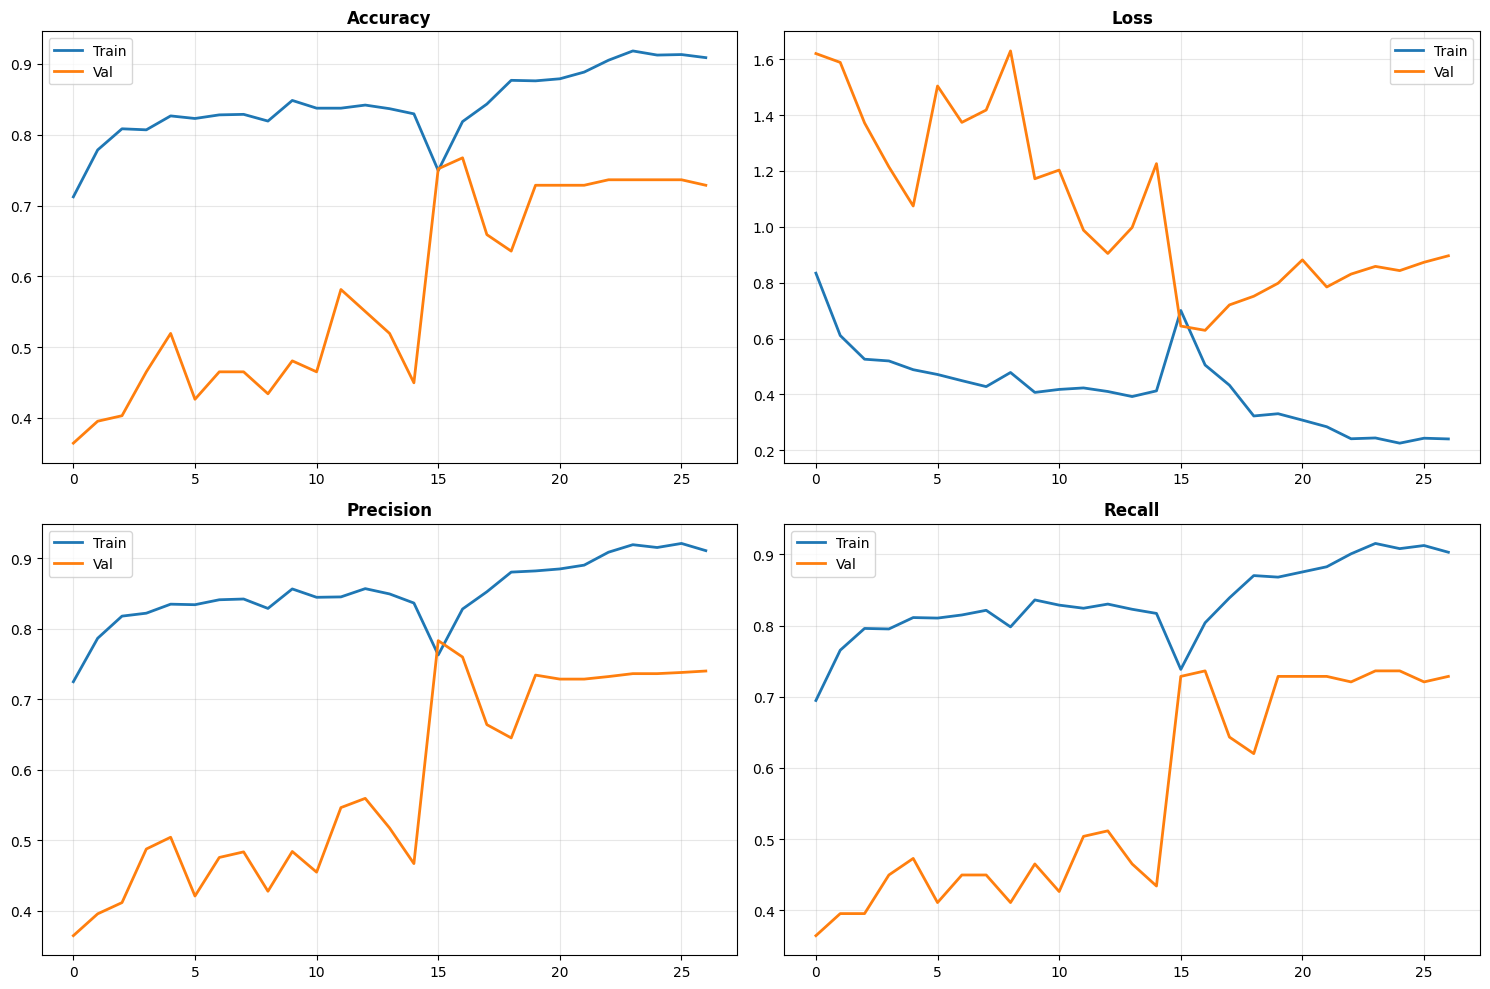


FINAL EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - accuracy: 0.7674 - f1_score: 0.7447 - loss: 0.6297 - precision: 0.7600 - recall: 0.7364

Validation Loss: 0.6297
Validation Accuracy: 0.7674
Validation Precision: 0.7600
Validation Recall: 0.7364
Validation F1-Score: 0.7447
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Classification Report:
              precision    recall  f1-score   support

        High     0.8627    0.9167    0.8889        48
         Low     0.8000    0.3529    0.4898        34
      Normal     0.6825    0.9149    0.7818        47

    accuracy                         0.7674       129
   macro avg     0.7818    0.7282    0.7202       129
weighted avg     0.7806    0.7674    0.7447       129



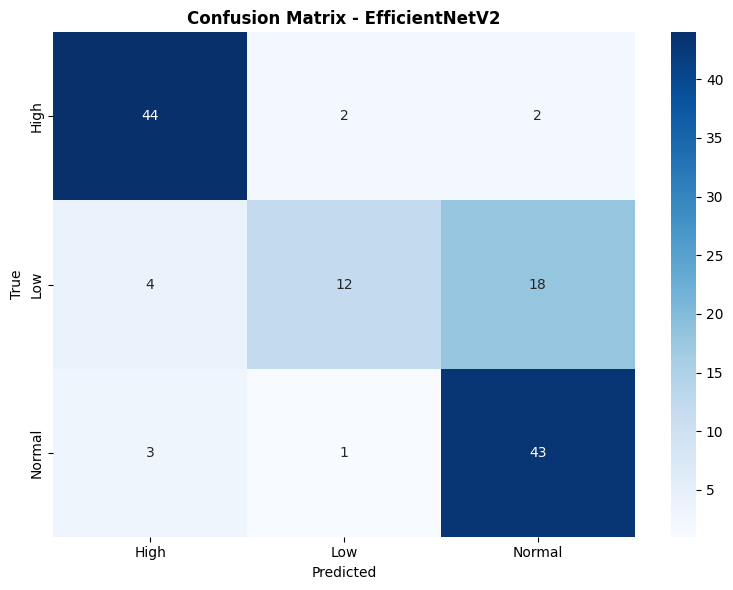


Per-class Accuracy:
  High: 44/48 = 0.9167
  Low: 12/34 = 0.3529
  Normal: 43/47 = 0.9149

Training complete!


In [ ]:
# ============================================================
# EfficientNetV2 for 3-Class Hemoglobin Classification
# FIXED: F1Score format issue
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile
import shutil
from sklearn.utils import class_weight
from google.colab import drive

# ============================================================
# 1. MOUNT & EXTRACT
# ============================================================

drive.mount('/content/drive')

zip_path = "Dataset not included — withheld pending publication"
extract_target_dir = "Dataset not included — withheld pending publication"

if os.path.exists(extract_target_dir):
    shutil.rmtree(extract_target_dir)
os.makedirs(extract_target_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_target_dir)

# Handle nested folder
actual_dataset_root = extract_target_dir
sub_dirs = [d for d in os.listdir(extract_target_dir)
            if os.path.isdir(os.path.join(extract_target_dir, d))]
if len(sub_dirs) == 1:
    actual_dataset_root = os.path.join(extract_target_dir, sub_dirs[0])

# Fix folder names
val_old = os.path.join(actual_dataset_root, 'Validation')
val_new = os.path.join(actual_dataset_root, 'validation')
if os.path.exists(val_old): os.rename(val_old, val_new)

for folder in ['train', 'validation']:
    normal_old = os.path.join(actual_dataset_root, folder, 'normal')
    normal_new = os.path.join(actual_dataset_root, folder, 'Normal')
    if os.path.exists(normal_old): os.rename(normal_old, normal_new)

# ============================================================
# 2. CONFIGURATION
# ============================================================

TRAIN_DIR = os.path.join(actual_dataset_root, "train")
VAL_DIR = os.path.join(actual_dataset_root, "validation")

IMG_SIZE = (100, 100)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 3
CLASS_NAMES = ['High', 'Low', 'Normal']

print(f"Train: {TRAIN_DIR}, Val: {VAL_DIR}")

# ============================================================
# 3. DATA GENERATORS (NO AUGMENTATION)
# ============================================================

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=True, seed=42)

val_data = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES, shuffle=False, seed=42)

print(f"\nTraining: {train_data.samples}, Validation: {val_data.samples}")

# ============================================================
# 4. CLASS WEIGHTS
# ============================================================

class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(train_data.classes), y=train_data.classes)
class_weights = dict(enumerate(class_weights))
print(f"Class weights: {class_weights}")

# ============================================================
# 5. BUILD EFFICIENTNETV2 MODEL
# ============================================================

def build_efficientnetv2_model():
    base_model = EfficientNetV2B0(
        weights='imagenet',
        include_top=False,
        input_shape=(100, 100, 3),
        include_preprocessing=False
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(100, 100, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_efficientnetv2_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.F1Score(name='f1_score', average='weighted')
    ]
)

print("\nModel Summary:")
model.summary()

# ============================================================
# 6. CALLBACKS
# ============================================================

callbacks = [
    ModelCheckpoint('efficientnetv2_best.keras', monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

# ============================================================
# 7. PHASE 1: TRAIN WITH FROZEN BASE
# ============================================================

print("\n" + "="*50)
print("PHASE 1: Training with frozen base")
print("="*50)

history_phase1 = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# 8. PHASE 2: FINE-TUNING
# ============================================================

print("\n" + "="*50)
print("PHASE 2: Fine-tuning")
print("="*50)

total_layers = len(base_model.layers)
fine_tune_at = int(total_layers * 0.7)

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print(f"Unfrozen {total_layers - fine_tune_at} layers")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.F1Score(name='f1_score', average='weighted')
    ]
)

history_phase2 = model.fit(
    train_data,
    epochs=EPOCHS,
    initial_epoch=len(history_phase1.history['loss']),
    validation_data=val_data,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# 9. COMBINE HISTORIES & PLOT
# ============================================================

def combine_histories(h1, h2):
    combined = {}
    for key in h1.history.keys():
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history = combine_histories(history_phase1, history_phase2)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].set_title('Accuracy', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history['val_loss'], label='Val', linewidth=2)
axes[0, 1].set_title('Loss', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# FIX: Handle F1Score which returns array
train_f1 = [f[0] if isinstance(f, np.ndarray) else f for f in history['f1_score']]
val_f1 = [f[0] if isinstance(f, np.ndarray) else f for f in history['val_f1_score']]

axes[1, 0].plot(history['precision'], label='Train', linewidth=2)
axes[1, 0].plot(history['val_precision'], label='Val', linewidth=2)
axes[1, 0].set_title('Precision', fontweight='bold')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history['recall'], label='Train', linewidth=2)
axes[1, 1].plot(history['val_recall'], label='Val', linewidth=2)
axes[1, 1].set_title('Recall', fontweight='bold')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_efficientnetv2.png', dpi=300)
plt.show()

# ============================================================
# 10. EVALUATE (FIXED)
# ============================================================

print("\n" + "="*50)
print("FINAL EVALUATION")
print("="*50)

best_model = keras.models.load_model('efficientnetv2_best.keras')

# Evaluate returns list, handle properly
eval_results = best_model.evaluate(val_data, verbose=1)
val_loss = eval_results[0]
val_acc = eval_results[1]
val_prec = eval_results[2]
val_rec = eval_results[3]
val_f1 = eval_results[4]

# FIX: Handle if F1 is array
if isinstance(val_f1, np.ndarray):
    val_f1 = val_f1[0]

print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Precision: {val_prec:.4f}")
print(f"Validation Recall: {val_rec:.4f}")
print(f"Validation F1-Score: {val_f1:.4f}")

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_data.reset()
y_pred = best_model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - EfficientNetV2', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_efficientnetv2-B0.png', dpi=300)
plt.show()

print("\nPer-class Accuracy:")
for i, name in enumerate(CLASS_NAMES):
    acc = cm[i, i] / np.sum(cm[i, :]) if np.sum(cm[i, :]) > 0 else 0
    print(f"  {name}: {cm[i, i]}/{np.sum(cm[i, :])} = {acc:.4f}")

best_model.save("Dataset not included — withheld pending publication")
print("\nTraining complete!")